In [48]:
### Code to read in h5 files as detailed in the first guidebook
# Import necessary packages
import sys

sys.path.append(r"C:\Users\lwlav\.vscode\repo\BOEM-Oak-Island\Post_Processing_Scripts")
import pandas as pd
import os
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy import signal
import glob
import utide
plt.rcParams.update({'font.size': 14}) 

deployment_num = [1,2,3,4,5]
sensor_spot = ["E","C","S"]
# directory_initial_user_path = r"/Volumes/BOEM/"  # Katherine
# directory_initial_user_path = r"/Volumes/kanarde/BOEM/"  # Brooke
directory_initial_user_path = r"Z:/"  # Levi

def tidal_ellipse(u,v,t,constituents = ['M2'], sensor = "S0",dep = "1",plotter = True):
 
    coef = utide.solve(t, u, v, lat=33.9, method="ols", conf_int="linear", constit=constituents)

    #With coefficients, we can reconstruct the tidal signal and plot the ellipses
    out = utide.reconstruct(t, coef)

    # Extract the fitted velocities
    u_fit = out.u
    v_fit = out.v
    if plotter == True:
        # Plotting the ellipse
        plt.figure(figsize=(6, 6))
        plt.plot(u_fit,v_fit, label='Reconstructed Tidal Ellipse')
        plt.axhline(0, color='black', lw=1, ls='--')
        plt.axvline(0, color='black', lw=1, ls='--')
        plt.xlabel("East Velocity (m/s)")
        plt.ylabel("North Velocity (m/s)")
        plt.title(f"Tidal Ellipse for {constituents[0]} - sensor {sensor} - Deployment {dep}")
        plt.axis('equal') # Crucial for seeing the true shape of the ellipse
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    #Remove tidal ellipse from original signal to get residuals
    u_residual = u - u_fit
    v_residual = v - v_fit

    return coef, out, pd.DataFrame({
        "U_residual": u_residual,
        "V_residual": v_residual
    })


In [49]:
# Import bulkstats and create dictionary for each sensor
for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")  # Extract S0 or S1
            sensor_serial = sensor_location[1]
            if sensor_serial == "103071" or dep ==5:
                files = ["SSC","Time","StokesTransport","DepthAveragedEastVelocity","DepthAveragedNorthVelocity","StokesDriftDirection"]
            else:
                files = ["SSC","Time","StokesTransport","DepthAveragedEastVelocity","DepthAveragedNorthVelocity","StokesDriftDirection"]
            waves = {}
            for file in files:
                file_path = os.path.join(sensor_id, file)  # file path
                df = pd.read_hdf(file_path)  # read the file into a Pandas dataframe
                file_name = file.split(".")[0]  # file name
                print(file_name)
                waves[file_name] = df  # store dataframe
            globals()[f"waves_{sensor_location[0]}_{dep}"] = waves
            

SSC
Time
StokesTransport
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
StokesDriftDirection
SSC
Time
StokesTransport
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
StokesDriftDirection
SSC
Time
StokesTransport
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
StokesDriftDirection
SSC
Time
StokesTransport
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
StokesDriftDirection
SSC
Time
StokesTransport
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
StokesDriftDirection
SSC
Time
StokesTransport
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
StokesDriftDirection
SSC
Time
StokesTransport
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
StokesDriftDirection
SSC
Time
StokesTransport
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
StokesDriftDirection
SSC
Time
StokesTransport
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
StokesDriftDirection
SSC
Time
StokesTransport
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
StokesDriftDirection
SSC
Time
S

In [97]:
for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:# Extract S0, S1, E1
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
            print(f"Processing {sensor_location}...")
            waves = globals()[f"waves_{sensor_location}_{dep}"]
            u = waves['DepthAveragedEastVelocity'].values.squeeze()
            v = waves['DepthAveragedNorthVelocity'].values.squeeze()
            t = waves['Time'].values.squeeze()
            transport = np.nanmean(waves['StokesTransport'],axis = 1)
            coef, out, resid = tidal_ellipse(u,v,t, plotter = 'False')

            eulerian_u = waves['SSC'].values.squeeze() * out.u
            eulerian_v = waves['SSC'].values.squeeze() * out.v

            stokes_u = transport * np.cos(np.deg2rad(np.nanmean(waves['StokesDriftDirection'],axis = 1)))
            stokes_v = transport * np.sin(np.deg2rad(np.nanmean(waves['StokesDriftDirection'], axis = 1)))

            waves['sum_ustokes'] = np.nansum(stokes_u)
            waves['sum_vstokes'] = np.nansum(stokes_v)
            waves['sum_ueuler'] = np.nansum(eulerian_u)
            waves['sum_veuler'] = np.nansum(eulerian_v)
            
            

Processing E1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S1...
solve: matrix prep ... solution ... 

C:\Users\lwlav\AppData\Local\Temp\ipykernel_24748\3175278835.py:13: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves['StokesTransport'],axis = 1)
C:\Users\lwlav\AppData\Local\Temp\ipykernel_24748\3175278835.py:13: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves['StokesTransport'],axis = 1)
C:\Users\lwlav\AppData\Local\Temp\ipykernel_24748\3175278835.py:13: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves['StokesTransport'],axis = 1)


done.
prep/calcs ... done.
Processing E1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.


C:\Users\lwlav\AppData\Local\Temp\ipykernel_24748\3175278835.py:13: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves['StokesTransport'],axis = 1)
C:\Users\lwlav\AppData\Local\Temp\ipykernel_24748\3175278835.py:13: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves['StokesTransport'],axis = 1)
C:\Users\lwlav\AppData\Local\Temp\ipykernel_24748\3175278835.py:13: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves['StokesTransport'],axis = 1)


Processing E0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing C0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing E1...
solve: matrix prep ... solution ... 

C:\Users\lwlav\AppData\Local\Temp\ipykernel_24748\3175278835.py:13: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves['StokesTransport'],axis = 1)
C:\Users\lwlav\AppData\Local\Temp\ipykernel_24748\3175278835.py:13: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves['StokesTransport'],axis = 1)


done.
prep/calcs ... done.
Processing S1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing C0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.


C:\Users\lwlav\AppData\Local\Temp\ipykernel_24748\3175278835.py:13: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves['StokesTransport'],axis = 1)


C:\Users\lwlav\AppData\Local\Temp\ipykernel_24748\2606183647.py:5: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves_E1_1['StokesTransport'],axis = 1)


solve: matrix prep ... solution ... done.
prep/calcs ... done.


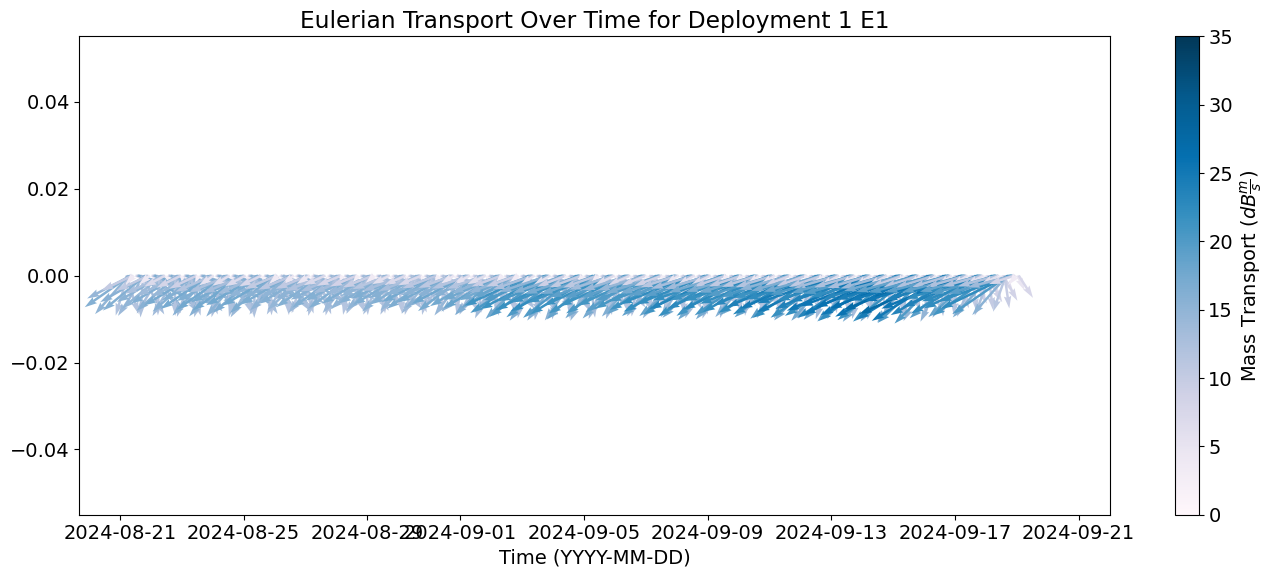

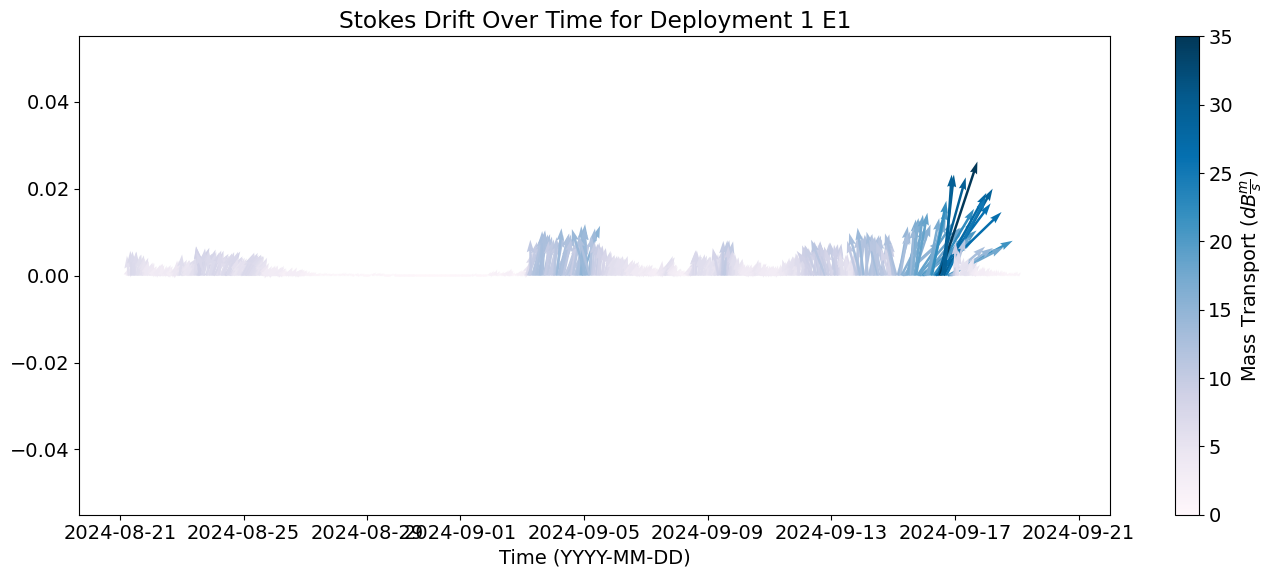

In [ ]:
# #Calculate eulerian transport
# u = waves_E1_1['DepthAveragedEastVelocity'].values.squeeze()
# v = waves_E1_1['DepthAveragedNorthVelocity'].values.squeeze()
# t = waves_E1_1['Time'].values.squeeze()
# transport = np.nanmean(waves_E1_1['StokesTransport'],axis = 1)
# coef, out, resid = tidal_ellipse(u,v,t, plotter = 'False')

# eulerian_u = waves_E1_1['SSC'].values.squeeze() * out.u
# eulerian_v = waves_E1_1['SSC'].values.squeeze() * out.v

# stokes_u = transport * np.cos(np.deg2rad(np.nanmean(waves_E1_1['StokesDriftDirection'],axis = 1)))
# stokes_v = transport * np.sin(np.deg2rad(np.nanmean(waves_E1_1['StokesDriftDirection'], axis = 1)))

# x = waves_E1_1['Time'].values.squeeze()
# y = np.zeros(len(x))
# euler_mag = np.sqrt(eulerian_u**2 + eulerian_v**2)

# norm = mcolors.Normalize (vmin = 0,vmax = 35)
# plt.figure(figsize=(14,6))
# q = plt.quiver(x,y,eulerian_u,eulerian_v,euler_mag,cmap = 'PuBu', label = 'Eulerian Transport',scale = 300, norm=norm)
# cmap = plt.colorbar(q, label = r'Mass Transport ($dB\frac{m}{s}$)')
# plt.title('Eulerian Transport Over Time for Deployment 1 E1')
# plt.xlabel('Time (YYYY-MM-DD)')
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14,6))
# q = plt.quiver(x,y,stokes_u,stokes_v,transport,cmap = 'PuBu', label = r'Stokes Transport',scale = 300,norm=norm)
# cmap = plt.colorbar(q, label = r'Mass Transport ($dB\frac{m}{s}$)')
# plt.title('Stokes Drift Over Time for Deployment 1 E1')
# plt.xlabel('Time (YYYY-MM-DD)')
# plt.tight_layout()
# plt.show()


['Z:/deployment_1/BulkStats\\E1_103071']
Processing E1...
[]
['Z:/deployment_1/BulkStats\\S0_103080', 'Z:/deployment_1/BulkStats\\S1_101418']
Processing S0...
Processing S1...
['Z:/deployment_2/BulkStats\\E1_103071']
Processing E1...
[]
['Z:/deployment_2/BulkStats\\S0_103080', 'Z:/deployment_2/BulkStats\\S1_101418']
Processing S0...
Processing S1...
['Z:/deployment_3/BulkStats\\E0_103080']
Processing E0...
['Z:/deployment_3/BulkStats\\C0_103071']
Processing C0...
['Z:/deployment_3/BulkStats\\S0_101418']
Processing S0...
['Z:/deployment_4/BulkStats\\E1_103071']
Processing E1...
[]
['Z:/deployment_4/BulkStats\\S1_103080']
Processing S1...
[]
['Z:/deployment_5/BulkStats\\C0_107730']
Processing C0...
['Z:/deployment_5/BulkStats\\S1_101481']
Processing S1...


Text(0.5, 1.0, 'Total Eulerian Mass Transport on FPS for All Deployments')

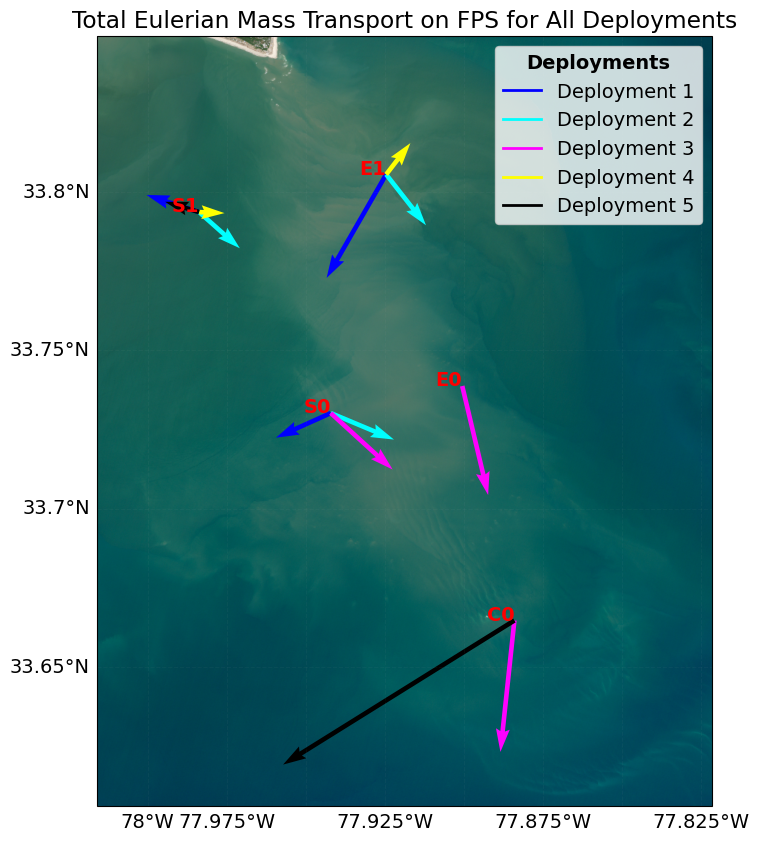

In [104]:
import rasterio
import cartopy.crs as ccrs
import matplotlib.lines as mlines#Plotter that overlays tidal ellipses from all deployments and landers on top of shoals 
# Convert dep to string to match filename parsing

filepath  = r"z:\deployment_3\2025-02-28-16bitTiff.tiff"

src = rasterio.open(filepath)
img16 = src.read()
# Basic normalization for 8-bit display
img8 = ((img16 - np.min(img16)) / (np.max(img16) - np.min(img16)) * 255).astype(np.uint8)

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": ccrs.PlateCarree()})

extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
ax.imshow(
    img8.transpose(1, 2, 0),
    origin="upper",
    extent=extent, 
    transform=ccrs.PlateCarree()
)

lander_coords = {
"S0": (-77.942100, 33.730200),
"S1": (-77.983700, 33.793700),
"C0": (-77.884083, 33.664683),
"E0": (-77.900567, 33.738750),
"E1": (-77.924600, 33.805600) # 33.805593 -77.924593$
}

deployment_colors = {
    1: 'blue',
    2: 'cyan',
    3: 'magenta',
    4: 'yellow',
    5: 'black',
}

for dep in deployment_num:
    dep_color = deployment_colors.get(dep, 'white')
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        print(sensor_ids)
        for sensor_id in sensor_ids:
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
            data = globals()[f"waves_{sensor_location}_{dep}"]
            print(f"Processing {sensor_location}...")


            # Get coords from dictionary, default to S0 if not found
            sensor = str(sensor_location)
            lon, lat = lander_coords.get(sensor, lander_coords["S0"])
            u = data['sum_ueuler']
            v = data['sum_veuler']

            # Plot the ellipse
            ax.quiver(lon, lat,u,v,color=dep_color, label=f"{sensor_location} - Deployment {dep}",scale = 30000)

            # Add a label for the lander
            if dep == 1:  # Only label for the first deployment to avoid clutter
                ax.text(lon, lat, sensor_location, transform=ccrs.PlateCarree(), 
                    fontsize=14, fontweight='bold', ha='right',color='red')

# Gridlines and Labels
gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.05)
gl.top_labels = False
gl.right_labels = False

#Add labels for E0 and C0
lon, lat = lander_coords.get("E0", (lander_coords["S0"]))
ax.text(lon, lat, "E0", transform=ccrs.PlateCarree(), 
                    fontsize=14, fontweight='bold', ha='right',color='red')
lon, lat = lander_coords.get("C0", (lander_coords["S0"]))
ax.text(lon, lat, "C0", transform=ccrs.PlateCarree(), 
                    fontsize=14, fontweight='bold', ha='right',color='red')

legend_elements = []

# Loop through your color dictionary and create a legend entry for each one
for dep_num, color in deployment_colors.items():
    line = mlines.Line2D([], [], color=color, linewidth=2, label=f'Deployment {dep_num}')
    legend_elements.append(line)

# Add the legend to the map with a nice title
ax.legend(handles=legend_elements, loc='upper right', title="Deployments", 
          title_fontproperties={'weight': 'bold'})

plt.title(f"Total Eulerian Mass Transport on FPS for All Deployments")

['Z:/deployment_1/BulkStats\\E1_103071']
Processing E1...
[]
['Z:/deployment_1/BulkStats\\S0_103080', 'Z:/deployment_1/BulkStats\\S1_101418']
Processing S0...
Processing S1...
['Z:/deployment_2/BulkStats\\E1_103071']
Processing E1...
[]
['Z:/deployment_2/BulkStats\\S0_103080', 'Z:/deployment_2/BulkStats\\S1_101418']
Processing S0...
Processing S1...
['Z:/deployment_3/BulkStats\\E0_103080']
Processing E0...
['Z:/deployment_3/BulkStats\\C0_103071']
Processing C0...
['Z:/deployment_3/BulkStats\\S0_101418']
Processing S0...
['Z:/deployment_4/BulkStats\\E1_103071']
Processing E1...
[]
['Z:/deployment_4/BulkStats\\S1_103080']
Processing S1...
[]
['Z:/deployment_5/BulkStats\\C0_107730']
Processing C0...
['Z:/deployment_5/BulkStats\\S1_101481']
Processing S1...


Text(0.5, 1.0, 'Total Stokes Mass Transport on FPS for All Deployments')

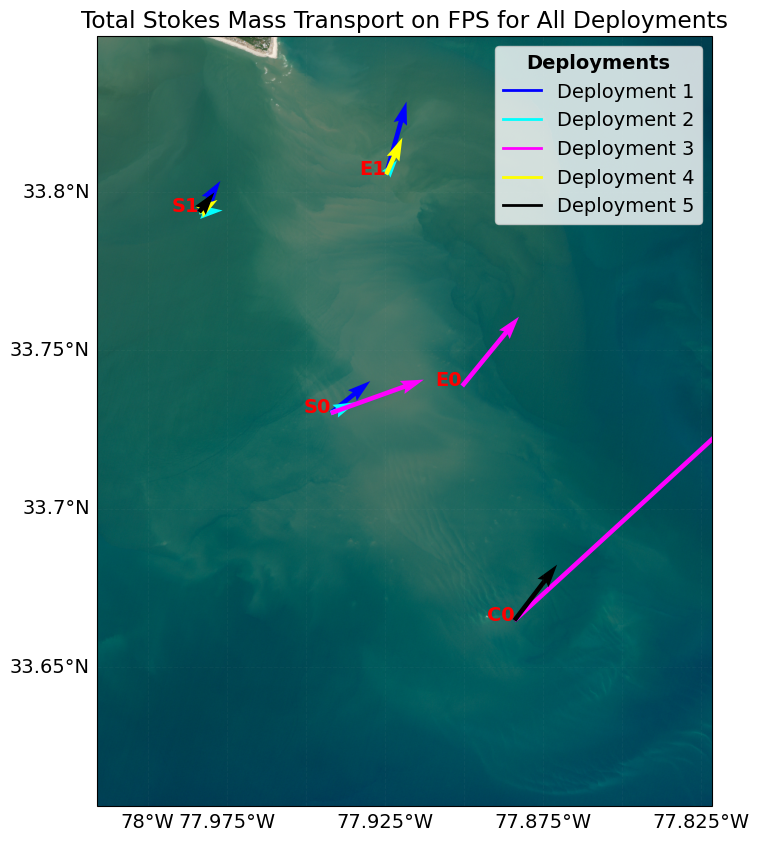

In [ ]:
import rasterio
import cartopy.crs as ccrs
import matplotlib.lines as mlines#Plotter that overlays tidal ellipses from all deployments and landers on top of shoals 
# Convert dep to string to match filename parsing

filepath  = r"z:\deployment_3\2025-02-28-16bitTiff.tiff"

src = rasterio.open(filepath)
img16 = src.read()
# Basic normalization for 8-bit display
img8 = ((img16 - np.min(img16)) / (np.max(img16) - np.min(img16)) * 255).astype(np.uint8)

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": ccrs.PlateCarree()})

extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
ax.imshow(
    img8.transpose(1, 2, 0),
    origin="upper",
    extent=extent, 
    transform=ccrs.PlateCarree()
)

lander_coords = {
"S0": (-77.942100, 33.730200),
"S1": (-77.983700, 33.793700),
"C0": (-77.884083, 33.664683),
"E0": (-77.900567, 33.738750),
"E1": (-77.924600, 33.805600) # 33.805593 -77.924593$
}

deployment_colors = {
    1: 'blue',
    2: 'cyan',
    3: 'magenta',
    4: 'yellow',
    5: 'black',
}

for dep in deployment_num:
    dep_color = deployment_colors.get(dep, 'white')
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
            data = globals()[f"waves_{sensor_location}_{dep}"]
            print(f"Processing {sensor_location}...")


            # Get coords from dictionary, default to S0 if not found
            sensor = str(sensor_location)
            lon, lat = lander_coords.get(sensor, lander_coords["S0"])
            u = data['sum_ustokes']
            v = data['sum_vstokes']
            

            # Plot the ellipse
            ax.quiver(lon, lat,u,v,color=dep_color, label=f"{sensor_location} - Deployment {dep}",scale = 30000)

            # Add a label for the lander
            if dep == 1:  # Only label for the first deployment to avoid clutter
                ax.text(lon, lat, sensor_location, transform=ccrs.PlateCarree(), 
                    fontsize=14, fontweight='bold', ha='right',color='red')

# Gridlines and Labels
gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.05)
gl.top_labels = False
gl.right_labels = False

#Add labels for E0 and C0
lon, lat = lander_coords.get("E0", (lander_coords["S0"]))
ax.text(lon, lat, "E0", transform=ccrs.PlateCarree(), 
                    fontsize=14, fontweight='bold', ha='right',color='red')
lon, lat = lander_coords.get("C0", (lander_coords["S0"]))
ax.text(lon, lat, "C0", transform=ccrs.PlateCarree(), 
                    fontsize=14, fontweight='bold', ha='right',color='red')

legend_elements = []

# Loop through your color dictionary and create a legend entry for each one
for dep_num, color in deployment_colors.items():
    line = mlines.Line2D([], [], color=color, linewidth=2, label=f'Deployment {dep_num}')
    legend_elements.append(line)

# Add the legend to the map with a nice title
ax.legend(handles=legend_elements, loc='upper right', title="Deployments", 
          title_fontproperties={'weight': 'bold'})

plt.title(f"Total Stokes Mass Transport on FPS for All Deployments")

Processing E1...
Processing S0...
Processing S1...
Processing E1...
Processing S0...
Processing S1...
Processing E0...
Processing C0...
Processing S0...
Processing E1...
Processing S1...
Processing C0...
Processing S1...


Text(0.5, 1.0, 'Total Mass Transport on FPS for All Deployments')

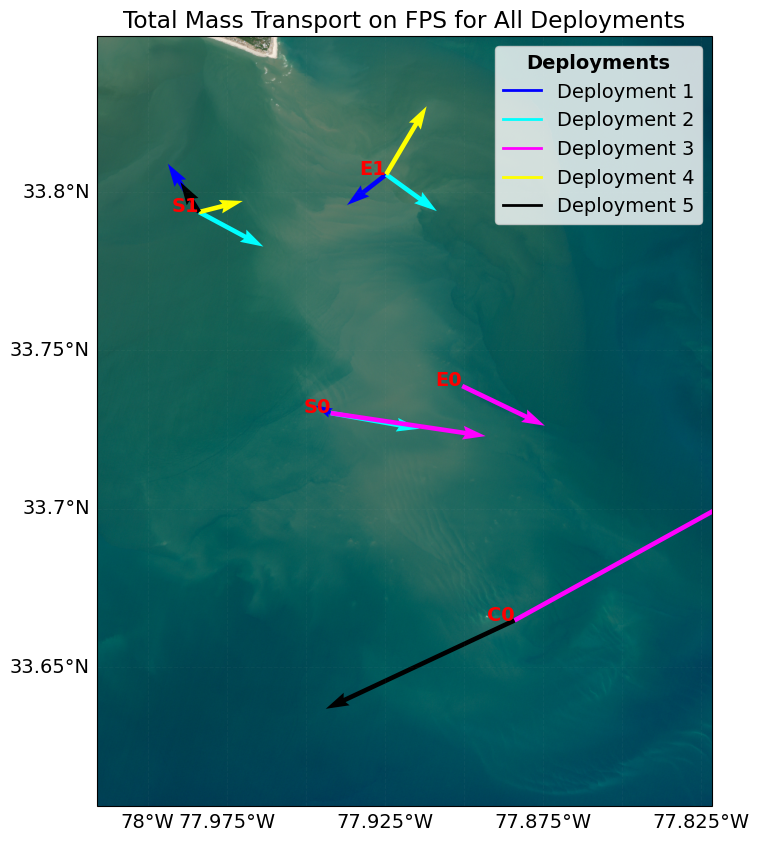

In [ ]:
import rasterio
import cartopy.crs as ccrs
import matplotlib.lines as mlines#Plotter that overlays tidal ellipses from all deployments and landers on top of shoals 
# Convert dep to string to match filename parsing

filepath  = r"z:\deployment_3\2025-02-28-16bitTiff.tiff"

src = rasterio.open(filepath)
img16 = src.read()
# Basic normalization for 8-bit display
img8 = ((img16 - np.min(img16)) / (np.max(img16) - np.min(img16)) * 255).astype(np.uint8)

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": ccrs.PlateCarree()})

extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
ax.imshow(
    img8.transpose(1, 2, 0),
    origin="upper",
    extent=extent, 
    transform=ccrs.PlateCarree()
)

lander_coords = {
"S0": (-77.942100, 33.730200),
"S1": (-77.983700, 33.793700),
"C0": (-77.884083, 33.664683),
"E0": (-77.900567, 33.738750),
"E1": (-77.924600, 33.805600) # 33.805593 -77.924593$
}

deployment_colors = {
    1: 'blue',
    2: 'cyan',
    3: 'magenta',
    4: 'yellow',
    5: 'black',
}

for dep in deployment_num:
    dep_color = deployment_colors.get(dep, 'white')
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
            data = globals()[f"waves_{sensor_location}_{dep}"]
            print(f"Processing {sensor_location}...")


            # Get coords from dictionary, default to S0 if not found
            sensor = str(sensor_location)
            lon, lat = lander_coords.get(sensor, lander_coords["S0"])
            u = data['sum_ustokes'] + data['sum_ueuler']
            v = data['sum_vstokes'] + data['sum_veuler']
            

            # Plot the ellipse
            ax.quiver(lon, lat,u,v,color=dep_color, label=f"{sensor_location} - Deployment {dep}",scale = 30000)

            # Add a label for the lander
            if dep == 1:  # Only label for the first deployment to avoid clutter
                ax.text(lon, lat, sensor_location, transform=ccrs.PlateCarree(), 
                    fontsize=14, fontweight='bold', ha='right',color='red')

# Gridlines and Labels
gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.05)
gl.top_labels = False
gl.right_labels = False

#Add labels for E0 and C0
lon, lat = lander_coords.get("E0", (lander_coords["S0"]))
ax.text(lon, lat, "E0", transform=ccrs.PlateCarree(), 
                    fontsize=14, fontweight='bold', ha='right',color='red')
lon, lat = lander_coords.get("C0", (lander_coords["S0"]))
ax.text(lon, lat, "C0", transform=ccrs.PlateCarree(), 
                    fontsize=14, fontweight='bold', ha='right',color='red')

legend_elements = []

# Loop through your color dictionary and create a legend entry for each one
for dep_num, color in deployment_colors.items():
    line = mlines.Line2D([], [], color=color, linewidth=2, label=f'Deployment {dep_num}')
    legend_elements.append(line)

# Add the legend to the map with a nice title
ax.legend(handles=legend_elements, loc='upper right', title="Deployments", 
          title_fontproperties={'weight': 'bold'})

plt.title(f"Mass Transport Directions on FPS for All Deployments")